# Unified Testing Notebook

This notebook wraps `src/test/test.py` and displays saved test visualizations.

Edit the config cell and run all cells.


In [4]:
# User-editable config
DATASET = 'irmas'      # options: chinese, irmas
FEATURE = 'cqt'        # options: mel, cqt, mel_cqt
TASK_MODE = 'single_label'  # or None -> infer from checkpoint
THRESHOLD = None       # None -> auto-tune (multi-label only)
WEIGHTS_RUN = 'IRMAS_cqt_single_label_v1'  # Optional run folder name
WEIGHTS_PATH = None    # Optional exact path to best_val.pt
TEST_MANIFEST = None   # Optional manifest override
CQT_BINS = None        # Optional: int, pass to --cqt_bins
BINS_PER_OCTAVE = 12   # Used with CQT path
NO_PROGRESS = False    # Disable tqdm progress bar in test.py
DEBUG = False


In [5]:
import shlex
import os
import subprocess
import sys
from pathlib import Path
import torch

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'src').exists() and (candidate / 'makefile').exists():
            return candidate
    raise RuntimeError('Cannot locate repo root from current notebook working directory.')

def default_run_name(dataset: str, feature: str, task_mode: str) -> str:
    prefix = 'Chinese' if dataset == 'chinese' else 'IRMAS'
    return f'{prefix}_{feature}_{task_mode}_v1'

def auto_pick_weights(repo_root: Path, dataset: str, feature: str) -> Path:
    for tm in ('multi_label', 'single_label'):
        run = default_run_name(dataset, feature, tm)
        p = (repo_root / 'src' / 'models' / 'saved_weights' / run / 'best_val.pt').resolve()
        if p.exists():
            return p
    fallback = default_run_name(dataset, feature, 'multi_label')
    return (repo_root / 'src' / 'models' / 'saved_weights' / fallback / 'best_val.pt').resolve()

def run_stream(cmd, cwd: Path, env: dict) -> None:
    proc = subprocess.Popen(
        cmd,
        cwd=str(cwd),
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=0,
    )
    assert proc.stdout is not None
    for raw in iter(proc.stdout.readline, b''):
        line = raw.decode('utf-8', errors='replace')
        print(line, end='')
    ret = proc.wait()
    if ret != 0:
        raise subprocess.CalledProcessError(ret, cmd)

repo_root = find_repo_root(Path.cwd())
python_exec = sys.executable
env = os.environ.copy()
env['PYTHONUNBUFFERED'] = '1'
env['PYTHONUTF8'] = '1'
env['PYTHONIOENCODING'] = 'utf-8'

if WEIGHTS_PATH:
    p = Path(WEIGHTS_PATH)
    resolved_weights_path = p if p.is_absolute() else (repo_root / p).resolve()
elif WEIGHTS_RUN:
    resolved_weights_path = (repo_root / 'src' / 'models' / 'saved_weights' / WEIGHTS_RUN / 'best_val.pt').resolve()
else:
    resolved_weights_path = auto_pick_weights(repo_root, DATASET, FEATURE)

cmd = [
    python_exec,
    '-u',
    'src/test/test.py',
    '--dataset', DATASET,
    '--feature', FEATURE,
]
if TASK_MODE:
    cmd.extend(['--task_mode', TASK_MODE])
if THRESHOLD is not None:
    cmd.extend(['--threshold', str(THRESHOLD)])
if WEIGHTS_RUN:
    cmd.extend(['--weights_run', WEIGHTS_RUN])
if WEIGHTS_PATH:
    cmd.extend(['--weights_path', str(WEIGHTS_PATH)])
if TEST_MANIFEST:
    cmd.extend(['--test_manifest', TEST_MANIFEST])
if CQT_BINS is not None:
    cmd.extend(['--cqt_bins', str(CQT_BINS)])
if BINS_PER_OCTAVE is not None:
    cmd.extend(['--bins_per_octave', str(BINS_PER_OCTAVE)])
if NO_PROGRESS:
    cmd.append('--no_progress')
if DEBUG:
    cmd.append('--debug')

print('Repo root:', repo_root)
print('Weights path candidate:', resolved_weights_path)
print('Running:', ' '.join(shlex.quote(x) for x in cmd))
run_stream(cmd, cwd=repo_root, env=env)

resolved_task_mode = TASK_MODE
if resolved_task_mode is None and resolved_weights_path.exists():
    ckpt = torch.load(resolved_weights_path, map_location='cpu')
    resolved_task_mode = str(ckpt.get('task_mode', 'multi_label')).strip().lower()
if resolved_task_mode is None:
    resolved_task_mode = 'multi_label'

resolved_plot_dir = resolved_weights_path.parent


Repo root: D:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound
Weights path candidate: D:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound\src\models\saved_weights\IRMAS_cqt_single_label_v1\best_val.pt
Running: 'd:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound\.venv\Scripts\python.exe' -u src/test/test.py --dataset irmas --feature cqt --task_mode single_label --weights_run IRMAS_cqt_single_label_v1 --bins_per_octave 12
Repo root: D:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound
Test mode: dataset=irmas, feature=cqt, task_mode=single_label, backbone=densenet121, weights_run=IRMAS_cqt_single_label_v1
Running inference on 807 samples against 11 classes...
100%|██████████| 807/807 [00:08<00:00, 93.17it/s]
[WARN] Found 505 samples with multi-positive GT in single-label eval; using argmax target.
Single-label accuracy: 0.3160
Single-label macro F1: 0.2096

--- Classification Report ---
              precision    re

Visualization target feature: CQT
Resolved task mode: single_label
Eval PNG: D:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound\src\models\saved_weights\IRMAS_cqt_single_label_v1\test_eval_single_cqt.png


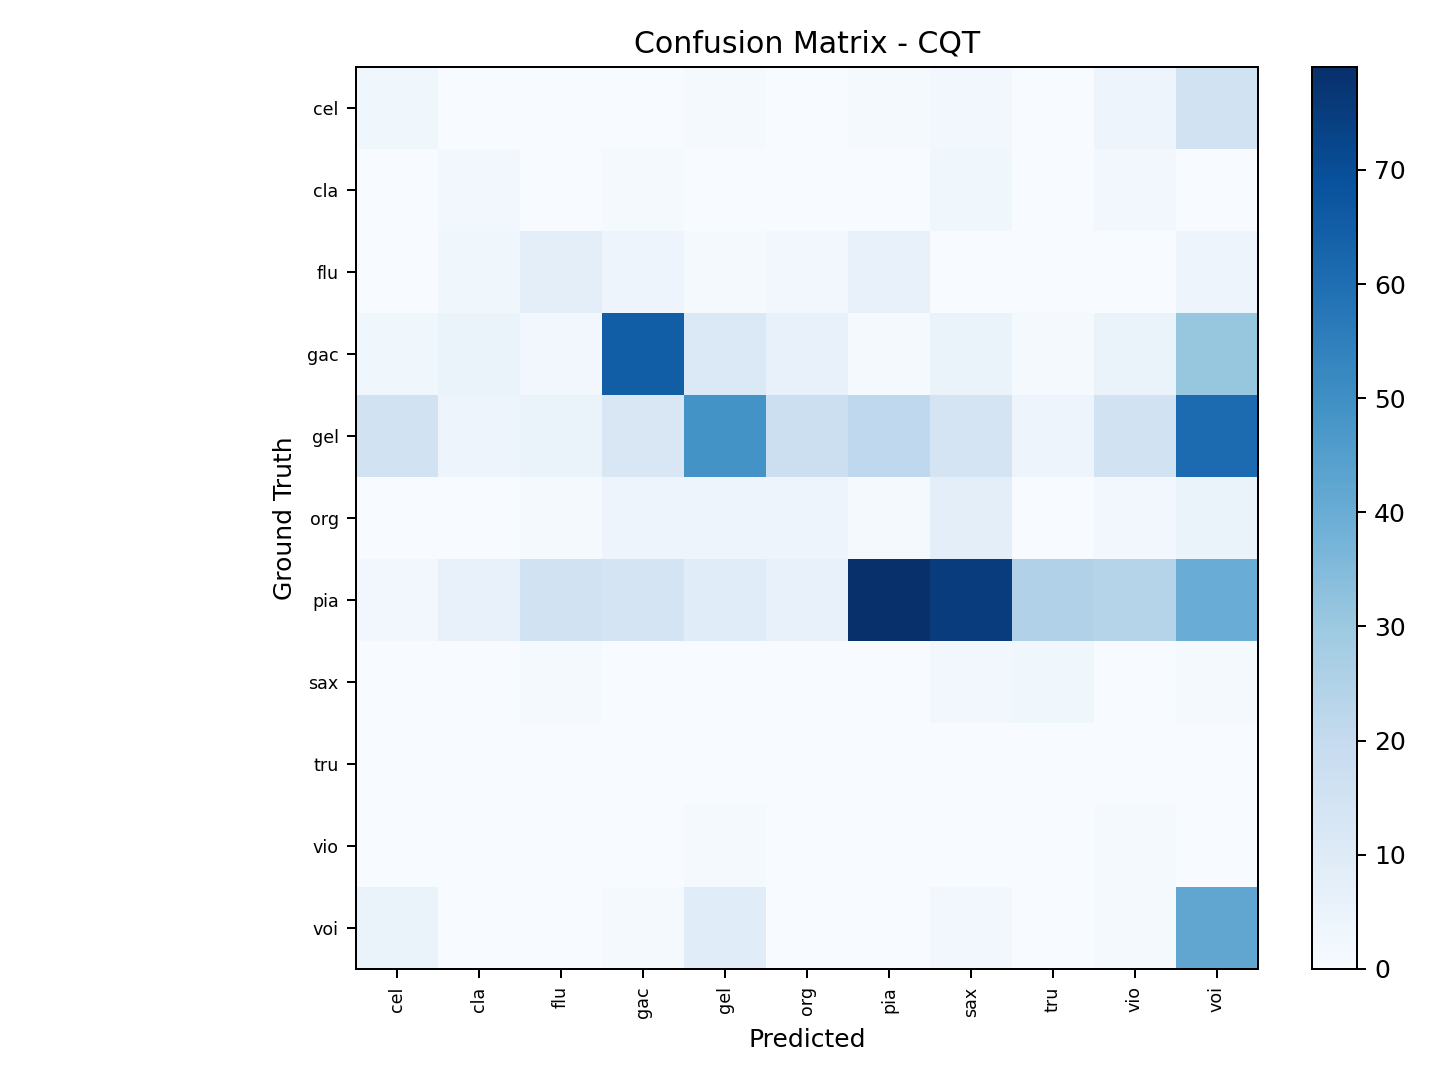

In [6]:
from pathlib import Path
from IPython.display import Image, display

feature_name = {'mel': 'Mel', 'cqt': 'CQT', 'mel_cqt': 'Mel + CQT'}.get(FEATURE, FEATURE)
if resolved_task_mode == 'single_label':
    eval_png = resolved_plot_dir / f'test_eval_single_{FEATURE}.png'
else:
    eval_png = resolved_plot_dir / f'test_eval_multilabel_{FEATURE}.png'

print(f'Visualization target feature: {feature_name}')
print(f'Resolved task mode: {resolved_task_mode}')
print('Eval PNG:', eval_png)

if eval_png.exists():
    display(Image(filename=str(eval_png)))
else:
    print('[WARN] Test visualization image not found. Check test logs and checkpoint folder.')
